In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent
TABLES = ROOT / "tables1"

subjects = [
    "YFF", "YFI", "YFJ", "YFK", "YFL",
    "YFM", "YFP", "YFS", "YFT", "YFU"
]

dfs = {}

for subject in subjects:
    path = TABLES / f"pairing_{subject}_fast.csv"
    df = pd.read_csv(path)
    dfs[subject] = df

    print(f"{subject}: {df.shape}")

print("\nColumns:")
print(dfs["YFF"].columns.tolist())

YFF: (666, 20)
YFI: (406, 20)
YFJ: (990, 20)
YFK: (946, 20)
YFL: (1540, 20)
YFM: (1830, 20)
YFP: (903, 20)
YFS: (1711, 20)
YFT: (1326, 20)
YFU: (1891, 20)

Columns:
['subject', 'neuron_1', 'neuron_2', 'n_presentations', 'min_class_count', 'n_splits', 'FR_accuracy', 'FR_best_gamma', 'FR_null_mean', 'FR_null_sd', 'FR_p', 'FR_coding', 'TC_accuracy', 'TC_best_bin_ms', 'TC_best_gamma', 'TC_null_mean', 'TC_null_sd', 'TC_p', 'TC_coding', 'TC_minus_FR']


In [2]:
# Combine all completed subjects
pairs = pd.concat(dfs.values(), ignore_index=True)

print("Total pairs:", len(pairs))
print("Subjects:", pairs["subject"].nunique())

summary = (
    pairs.groupby("subject")
    .agg(
        n_pairs=("TC_accuracy", "size"),
        mean_FR_accuracy=("FR_accuracy", "mean"),
        mean_TC_accuracy=("TC_accuracy", "mean"),
        median_TC_accuracy=("TC_accuracy", "median"),
        mean_TC_minus_FR=("TC_minus_FR", "mean"),
        FR_coding_pairs=("FR_coding", "sum"),
        TC_coding_pairs=("TC_coding", "sum"),
    )
)

summary["FR_coding_pct"] = 100 * summary["FR_coding_pairs"] / summary["n_pairs"]
summary["TC_coding_pct"] = 100 * summary["TC_coding_pairs"] / summary["n_pairs"]

summary.round(4)

Total pairs: 12209
Subjects: 10


,n_pairs,mean_FR_accuracy,mean_TC_accuracy,median_TC_accuracy,mean_TC_minus_FR,FR_coding_pairs,TC_coding_pairs,FR_coding_pct,TC_coding_pct
subject,,,,,,,,,
YFF,666,0.1142,0.1675,0.1651,0.0533,23,240,3.4535,36.0360
YFI,406,0.1191,0.1653,0.1635,0.0462,29,123,7.1429,30.2956
YFJ,990,0.1111,0.1673,0.1667,0.0562,70,378,7.0707,38.1818
YFK,946,0.1235,0.1719,0.1667,0.0484,91,393,9.6195,41.5433
YFL,1540,0.1057,0.1576,0.1579,0.0518,52,358,3.3766,23.2468
YFM,1830,0.1051,0.1671,0.1667,0.0620,82,666,4.4809,36.3934
YFP,903,0.1130,0.1504,0.1519,0.0375,43,244,4.7619,27.0210
YFS,1711,0.1098,0.1427,0.1402,0.0328,47,550,2.7469,32.1449
YFT,1326,0.1176,0.1374,0.1363,0.0199,124,502,9.3514,37.8582


In [3]:
for path in sorted(TABLES.glob("*.csv")):
    name = path.name.lower()
    if "neuron" in name or "permutation" in name or "figure1m" in name:
        print(path.name)

figure1M_all_neuron_permutations.csv
figure1M_subject_summary.csv
figure1M_YFF_permutation.csv
figure1M_YFI_permutation.csv
figure1M_YFJ_permutation.csv
figure1M_YFK_permutation.csv
figure1M_YFL_permutation.csv
figure1M_YFM_permutation.csv
figure1M_YFP_permutation.csv
figure1M_YFR_permutation.csv
figure1M_YFS_permutation.csv
figure1M_YFT_permutation.csv
figure1M_YFU_permutation.csv
figure1S_neuron_preferred_numbers.csv
figure1S_unique_preferred_neurons.csv
YFF_noncoding_neuron_pair_success.csv
YFI_noncoding_neuron_pair_success.csv
YFU_neuron43_lda_vs_logistic.csv


In [4]:
single = pd.read_csv(TABLES / "figure1M_all_neuron_permutations.csv")

print("Shape:", single.shape)

print("\nColumns:")
print(single.columns.tolist())

print("\nFirst 5 rows:")
display(single.head())

Shape: (552, 16)

Columns:
['subject', 'neuron', 'region', 'FR_accuracy', 'TC_accuracy', 'best_bin_ms', 'best_gamma', 'n_presentations', 'n_splits', 'FR_null_mean', 'FR_p', 'FR_coding', 'TC_null_mean', 'TC_p', 'TC_coding', 'elapsed_seconds']

First 5 rows:


,subject,neuron,region,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,n_presentations,n_splits,FR_null_mean,FR_p,FR_coding,TC_null_mean,TC_p,TC_coding,elapsed_seconds
0,YFF,9,ent,0.100917,0.165138,180,0.2,109,7,0.106376,0.646766,False,0.105092,0.059701,False,12.667940
1,YFF,10,hpc,0.091743,0.155963,90,0.2,109,7,0.106881,0.731343,False,0.109266,0.094527,False,11.077304
2,YFF,11,hpc,0.110092,0.201835,100,0.5,109,7,0.109404,0.532338,False,0.107248,0.019900,True,10.417088
3,YFF,12,hpc,0.100917,0.174312,300,0.5,109,7,0.110459,0.641791,False,0.108165,0.049751,True,11.636312
4,YFF,13,hpc,0.146789,0.155963,100,0.8,109,7,0.104771,0.159204,False,0.113257,0.139303,False,11.468347


In [5]:
# Keep the single-neuron quantities we need
single_info = single[
    ["subject", "neuron", "TC_accuracy", "TC_p", "TC_coding"]
].copy()

# Add neuron 1 information
pairs_merged = pairs.merge(
    single_info,
    left_on=["subject", "neuron_1"],
    right_on=["subject", "neuron"],
    how="left"
)

pairs_merged = pairs_merged.rename(columns={
    "TC_accuracy_y": "neuron1_TC_accuracy",
    "TC_p_y": "neuron1_TC_p",
    "TC_coding_y": "neuron1_TC_coding"
}).drop(columns="neuron")

# Rename the pair quantities before the second merge
pairs_merged = pairs_merged.rename(columns={
    "TC_accuracy_x": "pair_TC_accuracy",
    "TC_p_x": "pair_TC_p",
    "TC_coding_x": "pair_TC_coding"
})

# Add neuron 2 information
pairs_merged = pairs_merged.merge(
    single_info,
    left_on=["subject", "neuron_2"],
    right_on=["subject", "neuron"],
    how="left"
)

pairs_merged = pairs_merged.rename(columns={
    "TC_accuracy": "neuron2_TC_accuracy",
    "TC_p": "neuron2_TC_p",
    "TC_coding": "neuron2_TC_coding"
}).drop(columns="neuron")

# Check that every pair found both constituent neurons
print("Total pairs:", len(pairs_merged))
print("Missing neuron 1:", pairs_merged["neuron1_TC_accuracy"].isna().sum())
print("Missing neuron 2:", pairs_merged["neuron2_TC_accuracy"].isna().sum())

Total pairs: 12209
Missing neuron 1: 0
Missing neuron 2: 0


In [6]:
# Best constituent neuron for each pair
pairs_merged["best_single_TC_accuracy"] = pairs_merged[
    ["neuron1_TC_accuracy", "neuron2_TC_accuracy"]
].max(axis=1)

# Gain from combining the two neurons
pairs_merged["pair_gain"] = (
    pairs_merged["pair_TC_accuracy"]
    - pairs_merged["best_single_TC_accuracy"]
)

# Did the pair outperform the better individual neuron?
pairs_merged["pair_improved"] = pairs_merged["pair_gain"] > 0

gain_summary = (
    pairs_merged.groupby("subject")
    .agg(
        n_pairs=("pair_gain", "size"),
        mean_pair_accuracy=("pair_TC_accuracy", "mean"),
        mean_best_single=("best_single_TC_accuracy", "mean"),
        mean_gain=("pair_gain", "mean"),
        median_gain=("pair_gain", "median"),
        n_improved=("pair_improved", "sum"),
    )
)

gain_summary["pct_improved"] = (
    100 * gain_summary["n_improved"] / gain_summary["n_pairs"]
)

# Express gains as percentage points
gain_summary["mean_gain_pp"] = 100 * gain_summary["mean_gain"]
gain_summary["median_gain_pp"] = 100 * gain_summary["median_gain"]

display(
    gain_summary[
        [
            "n_pairs",
            "mean_pair_accuracy",
            "mean_best_single",
            "mean_gain_pp",
            "median_gain_pp",
            "n_improved",
            "pct_improved",
        ]
    ].round(3)
)

,n_pairs,mean_pair_accuracy,mean_best_single,mean_gain_pp,median_gain_pp,n_improved,pct_improved
subject,,,,,,,
YFF,666,0.167,0.175,-0.792,-0.917,192,28.829
YFI,406,0.165,0.177,-1.205,-0.962,92,22.660
YFJ,990,0.167,0.175,-0.782,-0.877,281,28.384
YFK,946,0.172,0.181,-0.954,-0.877,280,29.598
YFL,1540,0.158,0.166,-0.815,-0.877,437,28.377
YFM,1830,0.167,0.174,-0.715,-0.877,547,29.891
YFP,903,0.150,0.155,-0.453,-0.633,276,30.565
YFS,1711,0.143,0.151,-0.804,-0.379,354,20.690
YFT,1326,0.137,0.142,-0.441,-0.210,387,29.186


In [7]:
# Both constituent neurons are individually noncoding
pairs_merged["both_noncoding"] = (
    (~pairs_merged["neuron1_TC_coding"].astype(bool))
    & (~pairs_merged["neuron2_TC_coding"].astype(bool))
)

# Both individually noncoding, but their pair is coding
pairs_merged["noncoding_to_coding"] = (
    pairs_merged["both_noncoding"]
    & pairs_merged["pair_TC_coding"].astype(bool)
)

nc_summary = (
    pairs_merged.groupby("subject")
    .agg(
        total_pairs=("pair_TC_accuracy", "size"),
        both_noncoding_pairs=("both_noncoding", "sum"),
        noncoding_to_coding=("noncoding_to_coding", "sum"),
    )
)

nc_summary["pct_noncoding_to_coding"] = (
    100
    * nc_summary["noncoding_to_coding"]
    / nc_summary["both_noncoding_pairs"]
)

display(nc_summary.round(2))

,total_pairs,both_noncoding_pairs,noncoding_to_coding,pct_noncoding_to_coding
subject,,,,
YFF,666,325,45,13.85
YFI,406,171,15,8.77
YFJ,990,435,58,13.33
YFK,946,351,33,9.40
YFL,1540,1081,148,13.69
YFM,1830,990,124,12.53
YFP,903,561,68,12.12
YFS,1711,741,51,6.88
YFT,1326,741,153,20.65


In [8]:
overall = {
    "total_pairs": len(pairs_merged),

    "mean_pair_accuracy":
        pairs_merged["pair_TC_accuracy"].mean(),

    "mean_best_single_accuracy":
        pairs_merged["best_single_TC_accuracy"].mean(),

    "mean_gain_pp":
        100 * pairs_merged["pair_gain"].mean(),

    "median_gain_pp":
        100 * pairs_merged["pair_gain"].median(),

    "pairs_improved":
        pairs_merged["pair_improved"].sum(),

    "pct_pairs_improved":
        100 * pairs_merged["pair_improved"].mean(),

    "both_noncoding_pairs":
        pairs_merged["both_noncoding"].sum(),

    "noncoding_to_coding":
        pairs_merged["noncoding_to_coding"].sum(),

    "pct_noncoding_to_coding":
        100 * (
            pairs_merged["noncoding_to_coding"].sum()
            / pairs_merged["both_noncoding"].sum()
        )
}

pd.Series(overall).round(3)

total_pairs                  12209.000
mean_pair_accuracy               0.153
mean_best_single_accuracy        0.161
mean_gain_pp                    -0.736
median_gain_pp                  -0.629
pairs_improved                3320.000
pct_pairs_improved              27.193
both_noncoding_pairs          6062.000
noncoding_to_coding            809.000
pct_noncoding_to_coding         13.345
dtype: float64

In [9]:
# Number of individually coding neurons in each pair: 0, 1, or 2
pairs_merged["n_coding_constituents"] = (
    pairs_merged["neuron1_TC_coding"].astype(int)
    + pairs_merged["neuron2_TC_coding"].astype(int)
)

category_map = {
    0: "Noncoding + Noncoding",
    1: "Coding + Noncoding",
    2: "Coding + Coding"
}

pairs_merged["pair_category"] = (
    pairs_merged["n_coding_constituents"].map(category_map)
)

combo_summary = (
    pairs_merged
    .groupby(["subject", "pair_category"], observed=True)
    .agg(
        n_pairs=("pair_TC_accuracy", "size"),
        pair_coding=("pair_TC_coding", "sum"),
        mean_pair_accuracy=("pair_TC_accuracy", "mean"),
        mean_best_single=("best_single_TC_accuracy", "mean"),
        mean_gain=("pair_gain", "mean"),
        n_improved=("pair_improved", "sum"),
    )
    .reset_index()
)

combo_summary["pair_coding_pct"] = (
    100 * combo_summary["pair_coding"] / combo_summary["n_pairs"]
)

combo_summary["improved_pct"] = (
    100 * combo_summary["n_improved"] / combo_summary["n_pairs"]
)

combo_summary["mean_gain_pp"] = 100 * combo_summary["mean_gain"]

display(
    combo_summary[
        [
            "subject",
            "pair_category",
            "n_pairs",
            "pair_coding",
            "pair_coding_pct",
            "mean_gain_pp",
            "improved_pct",
        ]
    ].round(2)
)

,subject,pair_category,n_pairs,pair_coding,pair_coding_pct,mean_gain_pp,improved_pct
0,YFF,Coding + Coding,55,38,69.09,-0.83,23.64
1,YFF,Coding + Noncoding,286,157,54.90,-1.28,24.13
2,YFF,Noncoding + Noncoding,325,45,13.85,-0.35,33.85
3,YFI,Coding + Coding,45,32,71.11,-0.68,31.11
4,YFI,Coding + Noncoding,190,76,40.00,-1.60,20.00
5,YFI,Noncoding + Noncoding,171,15,8.77,-0.90,23.39
6,YFJ,Coding + Coding,105,79,75.24,-0.21,40.95
7,YFJ,Coding + Noncoding,450,241,53.56,-1.35,21.11
8,YFJ,Noncoding + Noncoding,435,58,13.33,-0.34,32.87
9,YFK,Coding + Coding,136,123,90.44,-0.26,43.38


In [10]:
import matplotlib.pyplot as plt

order = [
    "Noncoding + Noncoding",
    "Coding + Noncoding",
    "Coding + Coding"
]

# Pooled summary across all 10 subjects
pooled_combo = (
    pairs_merged
    .groupby("pair_category")
    .agg(
        n_pairs=("pair_TC_accuracy", "size"),
        n_pair_coding=("pair_TC_coding", "sum"),
        mean_pair_accuracy=("pair_TC_accuracy", "mean"),
        mean_best_single=("best_single_TC_accuracy", "mean"),
        mean_gain=("pair_gain", "mean"),
        n_improved=("pair_improved", "sum"),
    )
    .reindex(order)
)

pooled_combo["pair_coding_pct"] = (
    100 * pooled_combo["n_pair_coding"] / pooled_combo["n_pairs"]
)

pooled_combo["improved_pct"] = (
    100 * pooled_combo["n_improved"] / pooled_combo["n_pairs"]
)

pooled_combo["mean_gain_pp"] = 100 * pooled_combo["mean_gain"]

display(pooled_combo.round(2))

,n_pairs,n_pair_coding,mean_pair_accuracy,mean_best_single,mean_gain,n_improved,pair_coding_pct,improved_pct,mean_gain_pp
pair_category,,,,,,,,,
Noncoding + Noncoding,6062,809,0.14,0.15,-0.00,1955,13.35,32.25,-0.33
Coding + Noncoding,5046,2532,0.16,0.17,-0.01,1013,50.18,20.08,-1.27
Coding + Coding,1101,845,0.18,0.18,-0.01,352,76.75,31.97,-0.51


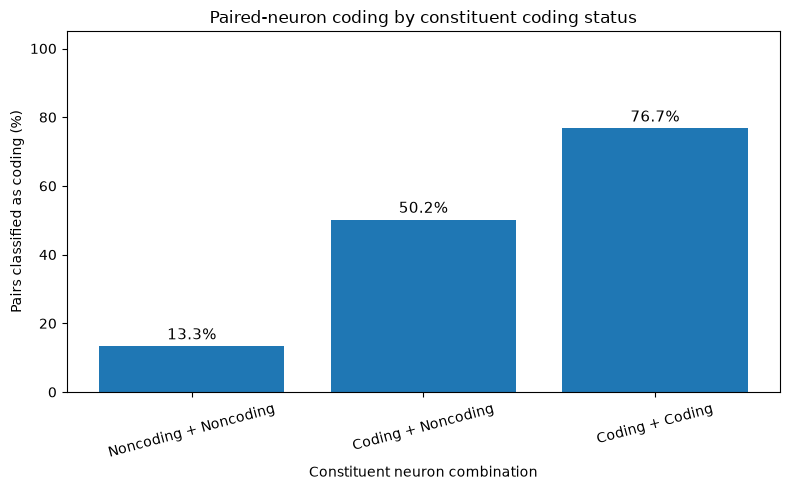

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    pooled_combo.index,
    pooled_combo["pair_coding_pct"]
)

ax.set_ylabel("Pairs classified as coding (%)")
ax.set_xlabel("Constituent neuron combination")
ax.set_title("Paired-neuron coding by constituent coding status")

ax.set_ylim(0, 105)

for bar, value in zip(bars, pooled_combo["pair_coding_pct"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

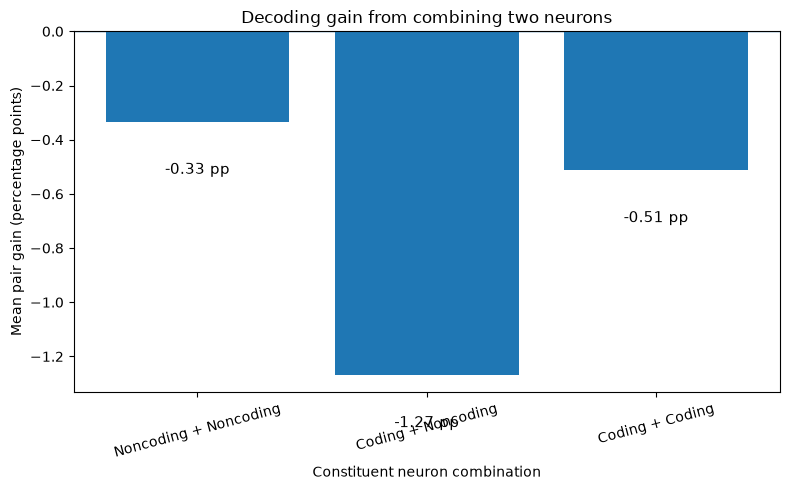

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    pooled_combo.index,
    pooled_combo["mean_gain_pp"]
)

ax.axhline(0, linewidth=1)

ax.set_ylabel("Mean pair gain (percentage points)")
ax.set_xlabel("Constituent neuron combination")
ax.set_title("Decoding gain from combining two neurons")

for bar, value in zip(bars, pooled_combo["mean_gain_pp"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + (0.05 if value >= 0 else -0.15),
        f"{value:+.2f} pp",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=11
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Across the 10 completed subjects and 12,209 pairs:
\[
\text{mean pair accuracy}=15.3\%
\]
versus
\[
\text{mean accuracy of better individual}=16.1\%.
\]